In [1]:
%load_ext autoreload
%autoreload 2
%reload_ext autoreload

import nest_asyncio
nest_asyncio.apply()

import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio
pio.renderers.default = "vscode"            

import matplotlib.pyplot as plt
import matplotlib.pylab as pylab
import matplotlib.dates as mdates
plt.style.use('seaborn-v0_8-dark')
params = {'legend.fontsize': 'x-large',
        'figure.figsize': (14, 9),
        'axes.labelsize': 'x-large',
        'axes.titlesize':'x-large',
        'xtick.labelsize':'x-large',
        'ytick.labelsize':'x-large'}
pylab.rcParams.update(params)

from TB.utils import make_secondary_axis_plot_v2 

import pandas as pd
import numpy as np

import datetime
import pytz
NY_tz = pytz.timezone("America/New_York") 
CHI_tz = pytz.timezone("America/Chicago") 
UTC_tz = pytz.timezone("UTC") 

In [2]:
from MDP.FixedRateBonds.FixedRateBondsMDP import FixedRateBondsMDP
from MDP.IRSwaps.IRSwapsMDP import IRSwapsMDP

from Query.FixedRateBonds.FixedRateBondQuery import FixedRateBondQuery
from Query.FixedRateBonds.FixedRateBondStructure import FixedRateBondStructure, FixedRateBondStructureFunctionMap
from Query.FixedRateBonds.FixedRateBondValue import FixedRateBondValue, FixedRateBondValueFunctionMap

from Query.IRSwaps.IRSwapQuery import IRSwapQuery
from Query.IRSwaps.IRSwapStructure import IRSwapStructure
from Query.IRSwaps.IRSwapValue import IRSwapValue

from TB.FixedRateBondsTB import FixedRateBondsTB
from TB.IRSwapsTB import IRSwapsTB
from TB.TimeseriesBuilder import TimeseriesBuilder

In [3]:
tb = TimeseriesBuilder(
    # irswaps_tb=IRSwapsTB(mdp=IRSwapsMDP(source="CME_NY_EOD_LIVE-ql_basic")),
    irswaps_tb=IRSwapsTB(mdp=IRSwapsMDP(source="CME_NY_EOD_LIVE-rl_basic")),
    fixedratebonds_tb=FixedRateBondsTB(mdp=FixedRateBondsMDP(source="USTS_FEDINVEST_WSJ_LIVE-QL")),
)

In [13]:
start = datetime.date(2024, 10, 1)
end = datetime.date(2025, 10, 13)

df = tb.get_timeseries(
    start=start,
    end=end,
    queries=[
        # FixedRateBondQuery(cusip="CT30", value=FixedRateBondValue.YTM), 
        # FixedRateBondQuery(cusip="CT2/CT5/CT10", value=FixedRateBondValue.YTM), 
        # FixedRateBondQuery(cusip="CT3/CT5/CT10", value=FixedRateBondValue.YTM), 
        # FixedRateBondQuery(cusip="CT2/CT5/CT7", value=FixedRateBondValue.YTM), 
        # FixedRateBondQuery(cusip="CT3/CT5/CT7", value=FixedRateBondValue.YTM), 
        # FixedRateBondQuery(cusip="oo2/oo10", value=FixedRateBondValue.YTM), 
        # IRSwapQuery(curve="USD-SOFR-1D", tenor="oo2/oo10", value=IRSwapValue.MMSS),
        IRSwapQuery(curve="USD-SOFR-1D", tenor="5Y", value=IRSwapValue.SPREADOVER),
        # IRSwapQuery(curve="USD-SOFR-1D", tenor="30Y", value=IRSwapValue.SPREADOVER),
        # IRSwapQuery(curve="USD-SOFR-1D", tenor="5Y/30Y", value=IRSwapValue.SPREADOVER),
        IRSwapQuery(curve="USD-SOFR-1D", tenor="CT5", value=IRSwapValue.MMSS),
        # IRSwapQuery(curve="USD-SOFR-1D", tenor="CT30", value=IRSwapValue.MMSS),
        # IRSwapQuery(curve="USD-SOFR-1D", tenor="CT5/CT30", value=IRSwapValue.MMSS),
        # IRSwapQuery(curve="USD-SOFR-1D", tenor="2Y/10Y", value=IRSwapValue.RATE),
        # IRSwapQuery(curve="USD-SOFR-1D", tenor="CT10", value=IRSwapValue.MMSS),
        # IRSwapQuery(curve="USD-SOFR-1D", tenor="10Y", value=IRSwapValue.SPREADOVER),
    ],
    n_jobs=5,
    # ignore_cache=True
)
df

PRICING USD-SOFR-1D IRSWAPS...: 100%|██████████| 514/514 [00:03<00:00, 158.57it/s]
PRICING FIXED-RATE BONDS.: 0it [00:00, ?it/s]


SWAPSPREADS                              
           USD-SOFR-1D 5Y OUTRIGHT SPREADOVER USD-SOFR-1D CT5 OUTRIGHT MMSS
Date                                                                       
2024-10-01                         -30.530274                    -30.533117
2024-10-02                         -30.783905                    -30.796338
2024-10-03                         -30.723692                    -30.746517
2024-10-04                         -31.500356                    -31.387734
2024-10-07                         -30.820226                    -30.783769
...                                       ...                           ...
2025-10-06                         -35.580935                    -35.713720
2025-10-07                         -34.658640                    -34.802503
2025-10-08                         -34.599337                    -34.754484
2025-10-09                         -34.743086                    -34.985205
2025-10-10                         -35.688250                    -35.860702

[257 rows x 2 columns]

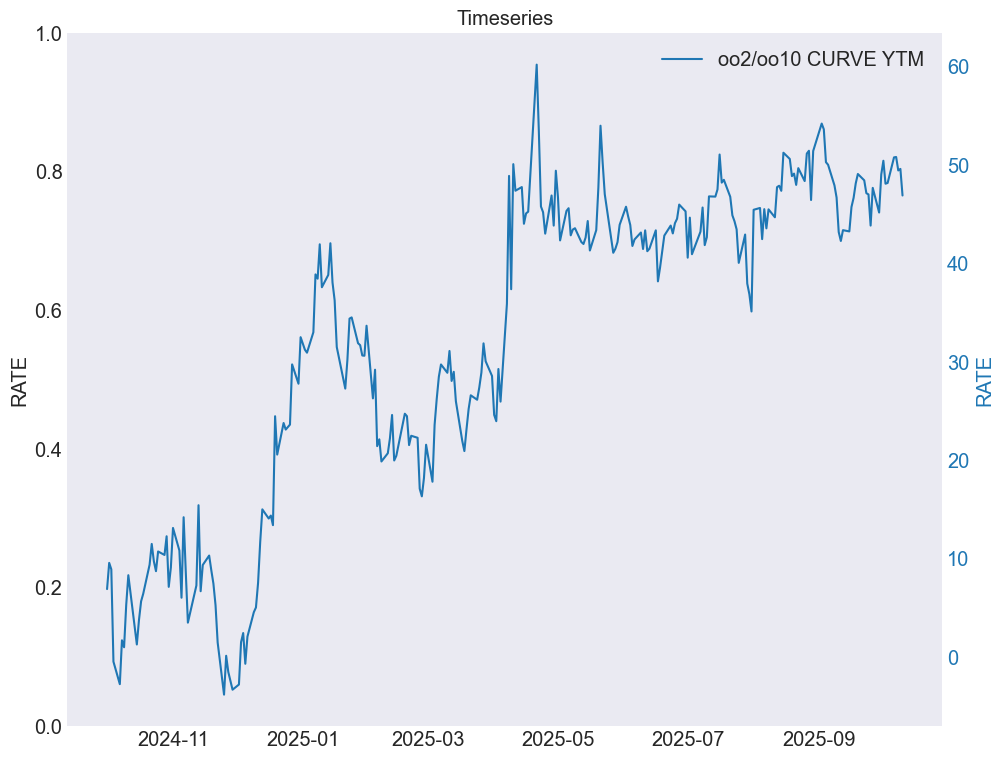

In [6]:
plot, fig, ax, ax2, legend = make_secondary_axis_plot_v2(
    ylabel_left="RATE",
    ylabel_right="RATE",
    title="Timeseries"
)

# plot(df["FRB"]["CT10 OUTRIGHT YTM"], which="left")
# plot(df["FRB"]["CT2/CT5/CT10 FLY YTM"], which="left")
# plot(df["FRB"]["CT3/CT5/CT10 FLY YTM"], which="left")
# plot(df["FRB"]["CT2/CT5/CT7 FLY YTM"], which="right")
# plot(df["FRB"]["CT3/CT5/CT7 FLY YTM"], which="right")
plot(df["FRB"]["oo2/oo10 CURVE YTM"], which="right")
# plot(df["SWAPSPREADS"]["USD-SOFR-1D CT10 OUTRIGHT MMSS"], which="left")
# plot(df["SWAPSPREADS"]["USD-SOFR-1D CT30 OUTRIGHT SPREADOVER"], which="right")
# plot(df["SWAPSPREADS"]["USD-SOFR-1D CT2/CT5/CT10 FLY MMSS"], which="right")
# plot(df["SWAPSPREADS"]["USD-SOFR-1D CT5/CT10 CURVE MMSS"], which="right")
# plot(df["SWAPSPREADS"]["USD-SOFR-1D 5Y/10Y CURVE SPREADOVER"], which="right")
# plot(df["IRS"]["USD-SOFR-1D 1y/1y1y/2y1y FLY RATE"], which="left")
# plot(df["IRS"]["USD-SOFR-1D 1y1y/2y1y/3y1y FLY RATE"])
# plot(df["IRS"]["USD-SOFR-1D 1y2y/1y5y/1y10y FLY RATE"], which="left")
# plot(df["IRS"]["USD-SOFR-1D 2y1y/3y1y/4y1y FLY RATE"])
# plot(df["IRS"]["USD-SOFR-1D 3y1y/4y1y/5y1y FLY RATE"])

# plot(df["SWAPSPREADS"]["USD-SOFR-1D 5Y/30Y CURVE SPREADOVER"], which="left")
# plot(df["SWAPSPREADS"]["USD-SOFR-1D CT5/CT30 CURVE MMSS"])
# plot(df["SWAPSPREADS"]["USD-SOFR-1D CT10 OUTRIGHT MMSS"])
# plot(df["SWAPSPREADS"]["USD-SOFR-1D 10Y OUTRIGHT SPREADOVER"])
# plot(df["FRB"]["CT30 OUTRIGHT YTM"])

legend()
plt.show()




# plt.plot(df.index, df["SWAPSPREADS"]["USD-SOFR-1D CT30 OUTRIGHT SPREADOVER"])